# Mental Health Happiness Index Prediction Project

This notebook demonstrates the use of different machine learning algorithms with hyperparameter tuning and regularization to predict the Happiness Index from mental health and lifestyle data.

## Project Overview
- **Objective**: Predict Happiness Index (1-10 scale) using mental health and lifestyle features
- **Approach**: Multiple ML algorithms with hyperparameter tuning and regularization
- **Dataset**: Mental Health Lifestyle Dataset with 11 features

## 1. Import Required Libraries

In [17]:
# Core Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Advanced ML Libraries
import xgboost as xgb
import lightgbm as lgb

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Utilities
from tqdm import tqdm
import joblib
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Load and Explore the Dataset

In [18]:
# Load the dataset
df = pd.read_csv('Mental_Health_Lifestyle_Dataset.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("Dataset Info:")
print("="*50)
df.info()

print("\n" + "="*50)
print("First 5 rows:")
print("="*50)
df.head()

Dataset Shape: (3000, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


In [19]:
# Basic statistics
print("="*50)
print("Descriptive Statistics:")
print("="*50)
df.describe()

print("\n" + "="*50)
print("Missing Values:")
print("="*50)
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

print("\n" + "="*50)
print("Unique values per column:")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(f"  Categories: {df[col].unique()[:10]}")  # Show first 10 categories
    print()

Descriptive Statistics:

Missing Values:
Country                          0
Age                              0
Gender                           0
Exercise Level                   0
Diet Type                        0
Sleep Hours                      0
Stress Level                     0
Mental Health Condition        595
Work Hours per Week              0
Screen Time per Day (Hours)      0
Social Interaction Score         0
Happiness Score                  0
dtype: int64

Total missing values: 595

Unique values per column:
Country: 7 unique values
  Categories: ['Brazil' 'Australia' 'Japan' 'Germany' 'India' 'Canada' 'USA']

Age: 47 unique values

Gender: 3 unique values
  Categories: ['Male' 'Female' 'Other']

Exercise Level: 3 unique values
  Categories: ['Low' 'Moderate' 'High']

Diet Type: 5 unique values
  Categories: ['Vegetarian' 'Vegan' 'Balanced' 'Junk Food' 'Keto']

Sleep Hours: 93 unique values

Stress Level: 3 unique values
  Categories: ['Low' 'High' 'Moderate']

Mental Hea

## 3. Data Preprocessing and Feature Engineering

In [20]:
# Create a copy for preprocessing
df_processed = df.copy()

# Handle categorical variables with label encoding for ordinal data and one-hot encoding for nominal data
categorical_cols = ['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']
numerical_cols = ['Age', 'Sleep Hours', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score']

print("Preprocessing categorical variables...")

# Label encoding for ordinal variables
ordinal_mappings = {
    'Exercise Level': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Stress Level': {'Low': 0, 'Moderate': 1, 'High': 2}
}

# Apply ordinal encoding
for col, mapping in ordinal_mappings.items():
    df_processed[col] = df_processed[col].map(mapping)

# One-hot encoding for nominal variables
nominal_cols = ['Country', 'Gender', 'Diet Type', 'Mental Health Condition']
df_processed = pd.get_dummies(df_processed, columns=nominal_cols, prefix=nominal_cols)

print("Shape after encoding:", df_processed.shape)
print("\nNew columns created:")
new_cols = [col for col in df_processed.columns if col not in df.columns]
print(new_cols[:10])  # Show first 10 new columns

Preprocessing categorical variables...
Shape after encoding: (3000, 27)

New columns created:
['Country_Australia', 'Country_Brazil', 'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_USA', 'Gender_Female', 'Gender_Male', 'Gender_Other']


In [21]:
# Feature Engineering: Create new features
print("Creating new features...")

# Sleep quality indicator (based on recommended 7-9 hours)
df_processed['Sleep_Quality'] = np.where(
    (df_processed['Sleep Hours'] >= 7) & (df_processed['Sleep Hours'] <= 9), 1, 0
)

# Work-life balance indicator
df_processed['Work_Life_Balance'] = np.where(
    df_processed['Work Hours per Week'] <= 40, 1, 0
)

# Screen time category
df_processed['High_Screen_Time'] = np.where(
    df_processed['Screen Time per Day (Hours)'] > 6, 1, 0
)

# Age groups
df_processed['Age_Group'] = pd.cut(df_processed['Age'], 
                                  bins=[0, 25, 35, 45, 55, 100], 
                                  labels=['18-25', '26-35', '36-45', '46-55', '55+'])
df_processed = pd.get_dummies(df_processed, columns=['Age_Group'], prefix='Age_Group')

print("Feature engineering completed!")
print(f"Final dataset shape: {df_processed.shape}")

# Display final feature list
print("\nFinal features:")
print(df_processed.columns.tolist())

Creating new features...
Feature engineering completed!
Final dataset shape: (3000, 35)

Final features:
['Age', 'Exercise Level', 'Sleep Hours', 'Stress Level', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score', 'Country_Australia', 'Country_Brazil', 'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_USA', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Diet Type_Balanced', 'Diet Type_Junk Food', 'Diet Type_Keto', 'Diet Type_Vegan', 'Diet Type_Vegetarian', 'Mental Health Condition_Anxiety', 'Mental Health Condition_Bipolar', 'Mental Health Condition_Depression', 'Mental Health Condition_PTSD', 'Sleep_Quality', 'Work_Life_Balance', 'High_Screen_Time', 'Age_Group_18-25', 'Age_Group_26-35', 'Age_Group_36-45', 'Age_Group_46-55', 'Age_Group_55+']


## 4. Exploratory Data Analysis and Visualization

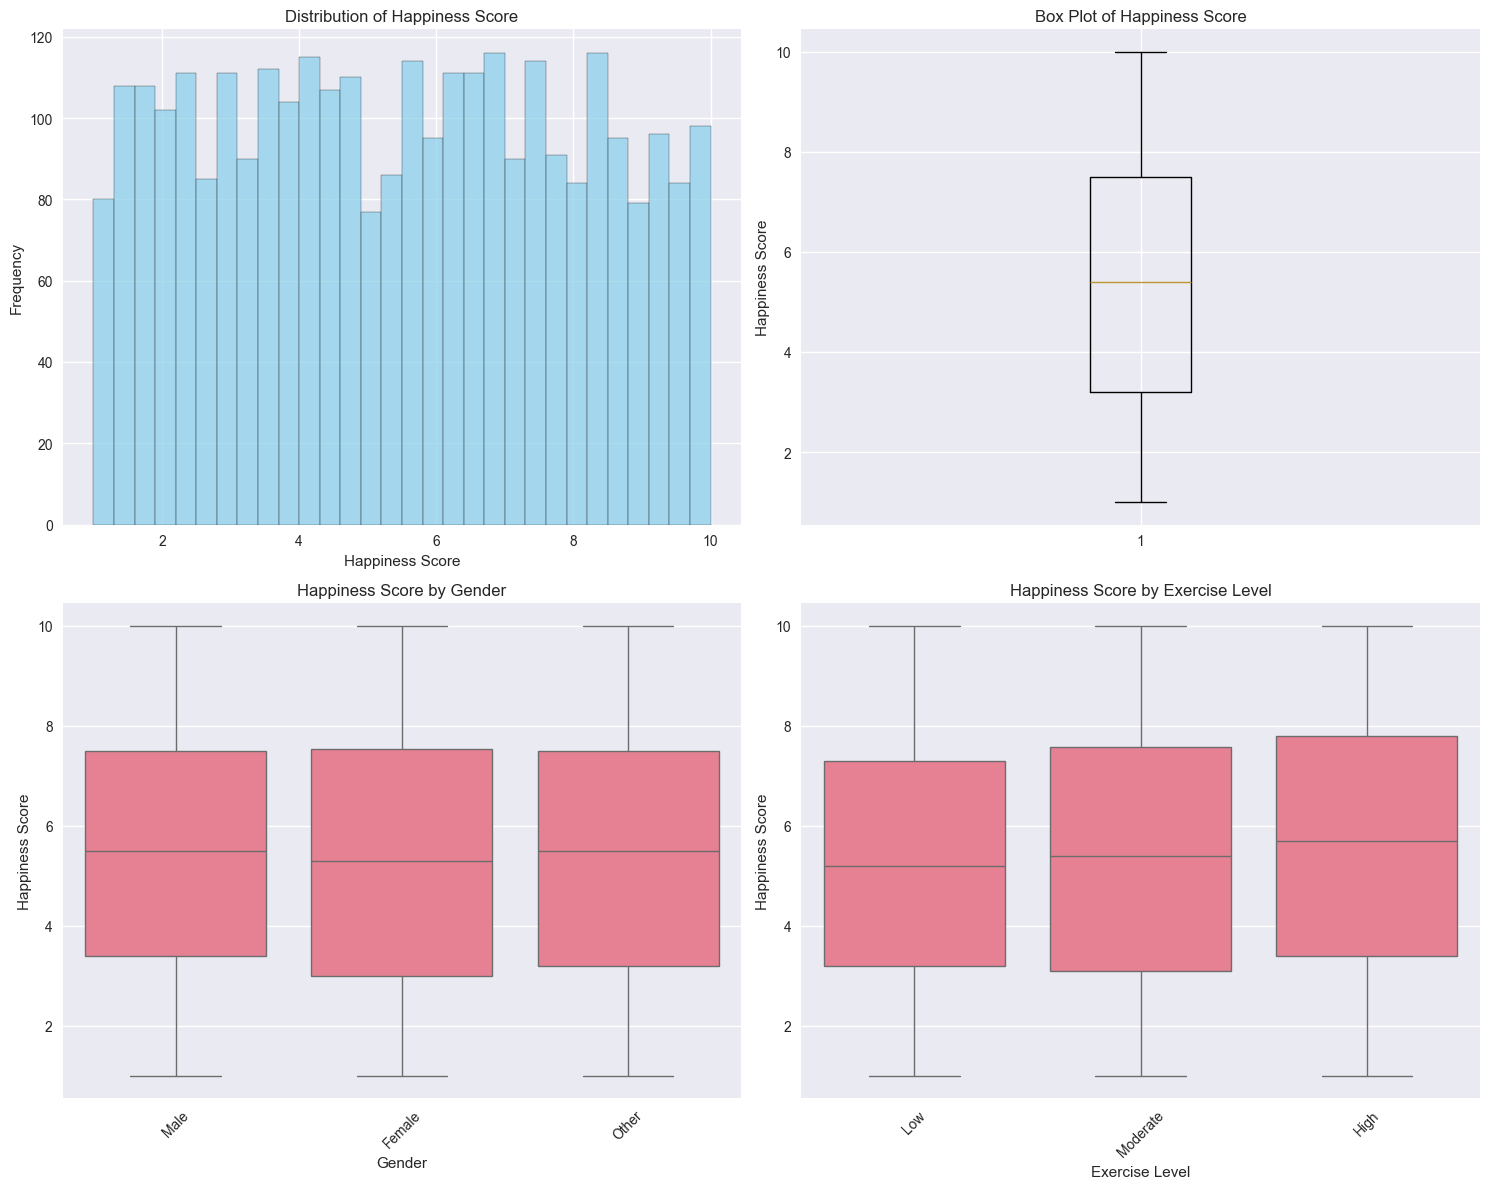

In [22]:
# Target variable distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram of Happiness Score
axes[0, 0].hist(df['Happiness Score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Happiness Score')
axes[0, 0].set_xlabel('Happiness Score')
axes[0, 0].set_ylabel('Frequency')

# Box plot of Happiness Score
axes[0, 1].boxplot(df['Happiness Score'])
axes[0, 1].set_title('Box Plot of Happiness Score')
axes[0, 1].set_ylabel('Happiness Score')

# Happiness by Gender
sns.boxplot(data=df, x='Gender', y='Happiness Score', ax=axes[1, 0])
axes[1, 0].set_title('Happiness Score by Gender')
axes[1, 0].tick_params(axis='x', rotation=45)

# Happiness by Exercise Level
sns.boxplot(data=df, x='Exercise Level', y='Happiness Score', ax=axes[1, 1])
axes[1, 1].set_title('Happiness Score by Exercise Level')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

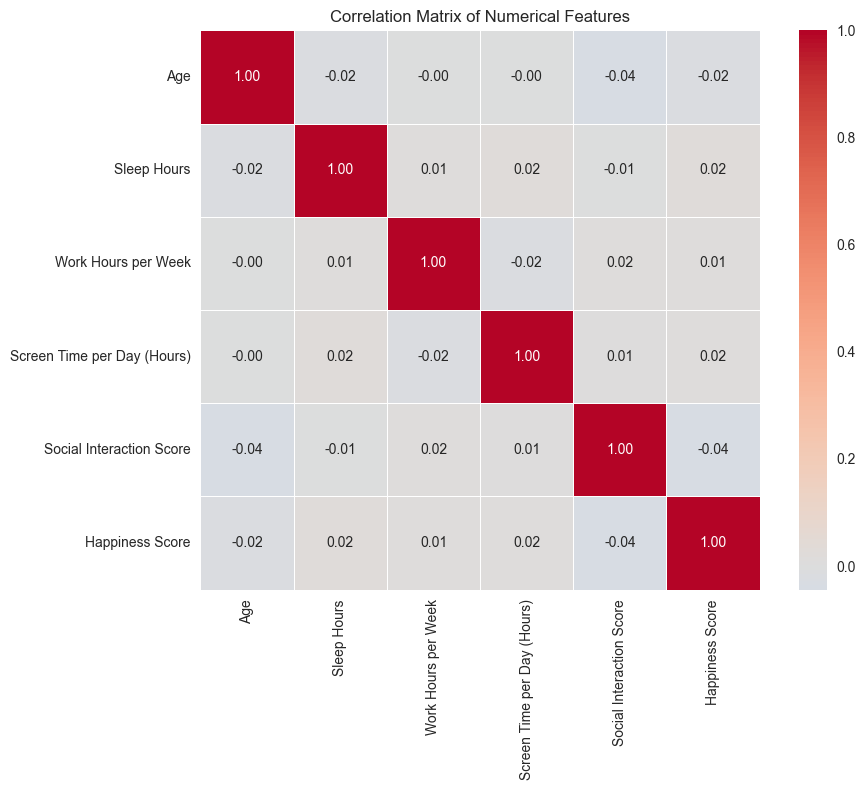

Correlations with Happiness Score:
Happiness Score                1.000000
Sleep Hours                    0.017389
Screen Time per Day (Hours)    0.016790
Work Hours per Week            0.010837
Age                           -0.015862
Social Interaction Score      -0.040236
dtype: float64


In [23]:
# Correlation analysis
numerical_features = ['Age', 'Sleep Hours', 'Work Hours per Week', 
                      'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']

# Calculate correlation matrix
corr_matrix = df[numerical_features].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Feature correlations with target variable
target_corr = df[numerical_features].corrwith(df['Happiness Score']).sort_values(ascending=False)
print("Correlations with Happiness Score:")
print(target_corr)

## 5. Train-Test Split

In [24]:
# Prepare features and target
X = df_processed.drop('Happiness Score', axis=1)
y = df_processed['Happiness Score']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.cut(y, bins=5)
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale numerical features
scaler = StandardScaler()

# Identify numerical columns for scaling (excluding binary encoded columns)
numerical_cols_scaled = ['Age', 'Sleep Hours', 'Work Hours per Week', 
                        'Screen Time per Day (Hours)', 'Social Interaction Score']

# Scale only numerical features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols_scaled] = scaler.fit_transform(X_train[numerical_cols_scaled])
X_test_scaled[numerical_cols_scaled] = scaler.transform(X_test[numerical_cols_scaled])

print("\nFeature scaling completed!")
print(f"Feature names: {X.columns.tolist()[:10]}...")  # Show first 10 features

Features shape: (3000, 34)
Target shape: (3000,)

Training set: 2400 samples
Test set: 600 samples

Feature scaling completed!
Feature names: ['Age', 'Exercise Level', 'Sleep Hours', 'Stress Level', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Country_Australia', 'Country_Brazil', 'Country_Canada']...


## 6. Linear Regression with Regularization

In [25]:
# Initialize models and results storage
models_results = {}

# 1. Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

models_results['Linear Regression'] = {
    'model': lr,
    'predictions': lr_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, lr_pred)),
    'mae': mean_absolute_error(y_test, lr_pred),
    'r2': r2_score(y_test, lr_pred)
}

print(f"Linear Regression - RMSE: {models_results['Linear Regression']['rmse']:.4f}")

# 2. Ridge Regression with fixed hyperparameters
print("\nTraining Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

models_results['Ridge Regression'] = {
    'model': ridge,
    'predictions': ridge_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, ridge_pred)),
    'mae': mean_absolute_error(y_test, ridge_pred),
    'r2': r2_score(y_test, ridge_pred)
}

print(f"Ridge Regression - Alpha: 1.0")
print(f"Ridge Regression - RMSE: {models_results['Ridge Regression']['rmse']:.4f}")

# 3. Lasso Regression with fixed hyperparameters
print("\nTraining Lasso Regression...")
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

models_results['Lasso Regression'] = {
    'model': lasso,
    'predictions': lasso_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, lasso_pred)),
    'mae': mean_absolute_error(y_test, lasso_pred),
    'r2': r2_score(y_test, lasso_pred)
}

print(f"Lasso Regression - Alpha: 0.1")
print(f"Lasso Regression - RMSE: {models_results['Lasso Regression']['rmse']:.4f}")

Training Linear Regression...
Linear Regression - RMSE: 2.5692

Training Ridge Regression...
Ridge Regression - Alpha: 1.0
Ridge Regression - RMSE: 2.5691

Training Lasso Regression...
Lasso Regression - Alpha: 0.1
Lasso Regression - RMSE: 2.5744


## 7. Random Forest Regressor

In [26]:
# Random Forest with base hyperparameters
print("Training Random Forest Regressor...")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

models_results['Random Forest'] = {
    'model': rf,
    'predictions': rf_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'mae': mean_absolute_error(y_test, rf_pred),
    'r2': r2_score(y_test, rf_pred)
}

print(f"Random Forest - Hyperparameters: n_estimators=100, max_depth=10")
print(f"Random Forest - RMSE: {models_results['Random Forest']['rmse']:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance.head(10))

Training Random Forest Regressor...
Random Forest - Hyperparameters: n_estimators=100, max_depth=10
Random Forest - RMSE: 2.5820

Top 10 most important features:
                        feature  importance
6      Social Interaction Score    0.145820
2                   Sleep Hours    0.139311
5   Screen Time per Day (Hours)    0.136057
4           Work Hours per Week    0.124326
0                           Age    0.111502
3                  Stress Level    0.031980
1                Exercise Level    0.029530
21         Diet Type_Vegetarian    0.015707
11                Country_India    0.014893
14                Gender_Female    0.014369
Random Forest - Hyperparameters: n_estimators=100, max_depth=10
Random Forest - RMSE: 2.5820

Top 10 most important features:
                        feature  importance
6      Social Interaction Score    0.145820
2                   Sleep Hours    0.139311
5   Screen Time per Day (Hours)    0.136057
4           Work Hours per Week    0.124326
0       

## 8. Support Vector Regression

In [27]:
# Support Vector Regression with base hyperparameters
print("Training Support Vector Regression...")

svr = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1,
    gamma='scale'
)
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

models_results['SVR'] = {
    'model': svr,
    'predictions': svr_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, svr_pred)),
    'mae': mean_absolute_error(y_test, svr_pred),
    'r2': r2_score(y_test, svr_pred)
}

print(f"SVR - Hyperparameters: kernel='rbf', C=1.0, epsilon=0.1")
print(f"SVR - RMSE: {models_results['SVR']['rmse']:.4f}")

Training Support Vector Regression...
SVR - Hyperparameters: kernel='rbf', C=1.0, epsilon=0.1
SVR - RMSE: 2.6158
SVR - Hyperparameters: kernel='rbf', C=1.0, epsilon=0.1
SVR - RMSE: 2.6158


## 9. Gradient Boosting Regressor

In [28]:
# XGBoost Regressor with base hyperparameters
print("Training XGBoost Regressor...")

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

models_results['XGBoost'] = {
    'model': xgb_model,
    'predictions': xgb_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'mae': mean_absolute_error(y_test, xgb_pred),
    'r2': r2_score(y_test, xgb_pred)
}

print(f"XGBoost - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1")
print(f"XGBoost - RMSE: {models_results['XGBoost']['rmse']:.4f}")

# LightGBM Regressor with base hyperparameters
print("\nTraining LightGBM Regressor...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    reg_alpha=0,
    reg_lambda=0,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_scaled, y_train)
lgb_pred = lgb_model.predict(X_test_scaled)

models_results['LightGBM'] = {
    'model': lgb_model,
    'predictions': lgb_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, lgb_pred)),
    'mae': mean_absolute_error(y_test, lgb_pred),
    'r2': r2_score(y_test, lgb_pred)
}

print(f"LightGBM - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1")
print(f"LightGBM - RMSE: {models_results['LightGBM']['rmse']:.4f}")

Training XGBoost Regressor...
XGBoost - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1
XGBoost - RMSE: 2.6869

Training LightGBM Regressor...
XGBoost - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1
XGBoost - RMSE: 2.6869

Training LightGBM Regressor...
LightGBM - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1
LightGBM - RMSE: 2.6485
LightGBM - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1
LightGBM - RMSE: 2.6485


## 10. Neural Network (Multi-layer Perceptron)

Training Neural Network with TensorFlow/Keras...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Neural Network - RMSE: 2.6604
Neural Network - RMSE: 2.6604


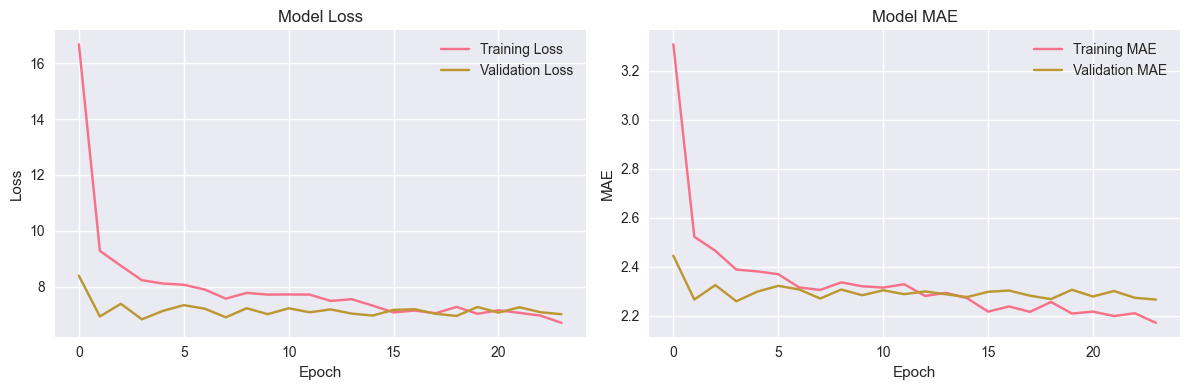

In [29]:
# Deep Learning with TensorFlow/Keras
print("Training Neural Network with TensorFlow/Keras...")

# Define function to create neural network
def create_neural_network(input_dim, hidden_layers=[64, 32], dropout_rate=0.2, learning_rate=0.001):
    model = keras.Sequential()
    
    # Input layer
    model.add(layers.Dense(hidden_layers[0], activation='relu', input_shape=(input_dim,)))
    model.add(layers.Dropout(dropout_rate))
    
    # Hidden layers
    for units in hidden_layers[1:]:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    
    # Output layer
    model.add(layers.Dense(1, activation='linear'))
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Create and train the neural network
nn_model = create_neural_network(
    input_dim=X_train_scaled.shape[1], 
    hidden_layers=[128, 64, 32], 
    dropout_rate=0.3, 
    learning_rate=0.001
)

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

# Train the model
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

# Make predictions
nn_pred = nn_model.predict(X_test_scaled).flatten()

models_results['Neural Network'] = {
    'model': nn_model,
    'predictions': nn_pred,
    'rmse': np.sqrt(mean_squared_error(y_test, nn_pred)),
    'mae': mean_absolute_error(y_test, nn_pred),
    'r2': r2_score(y_test, nn_pred),
    'history': history
}

print(f"Neural Network - RMSE: {models_results['Neural Network']['rmse']:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

## 11. Model Evaluation and Comparison

Model Performance Comparison:
               Model    RMSE     MAE      R²
1   Ridge Regression  2.5691  2.2117  0.0040
0  Linear Regression  2.5692  2.2118  0.0039
2   Lasso Regression  2.5744  2.2224 -0.0002
3      Random Forest  2.5820  2.2154 -0.0061
4                SVR  2.6158  2.2403 -0.0326
6           LightGBM  2.6485  2.2552 -0.0585
7     Neural Network  2.6604  2.2702 -0.0681
5            XGBoost  2.6869  2.2787 -0.0895


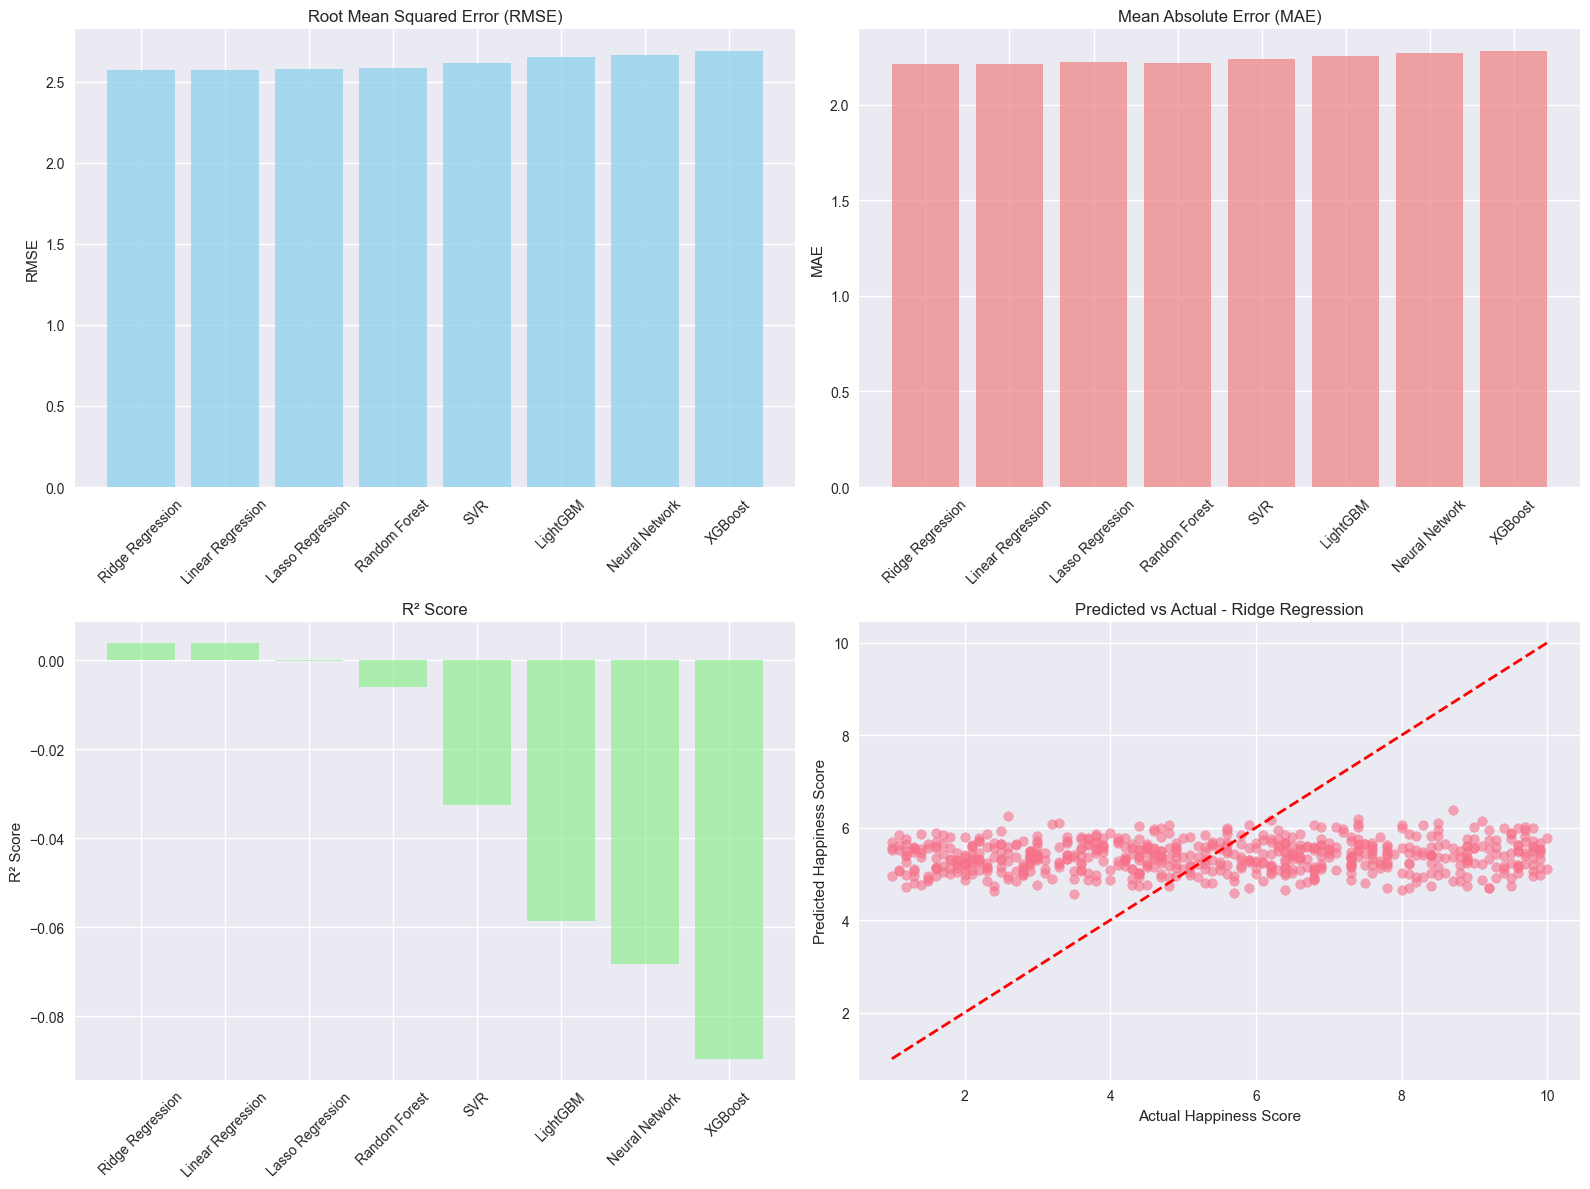


Best performing model: Ridge Regression
Best RMSE: 2.5691
Best R²: 0.0040


In [30]:
# Create comprehensive results comparison
results_df = pd.DataFrame({
    'Model': list(models_results.keys()),
    'RMSE': [results['rmse'] for results in models_results.values()],
    'MAE': [results['mae'] for results in models_results.values()],
    'R²': [results['r2'] for results in models_results.values()]
}).sort_values('RMSE')

print("Model Performance Comparison:")
print("="*60)
print(results_df.round(4))

# Visualize model performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE comparison
axes[0, 0].bar(results_df['Model'], results_df['RMSE'], color='skyblue', alpha=0.7)
axes[0, 0].set_title('Root Mean Squared Error (RMSE)')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[0, 1].bar(results_df['Model'], results_df['MAE'], color='lightcoral', alpha=0.7)
axes[0, 1].set_title('Mean Absolute Error (MAE)')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=45)

# R² comparison
axes[1, 0].bar(results_df['Model'], results_df['R²'], color='lightgreen', alpha=0.7)
axes[1, 0].set_title('R² Score')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].tick_params(axis='x', rotation=45)

# Predicted vs Actual for best model
best_model_name = results_df.iloc[0]['Model']
best_predictions = models_results[best_model_name]['predictions']

axes[1, 1].scatter(y_test, best_predictions, alpha=0.6)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Happiness Score')
axes[1, 1].set_ylabel('Predicted Happiness Score')
axes[1, 1].set_title(f'Predicted vs Actual - {best_model_name}')

plt.tight_layout()
plt.show()

print(f"\nBest performing model: {best_model_name}")
print(f"Best RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"Best R²: {results_df.iloc[0]['R²']:.4f}")

## 12. Feature Importance Analysis

Feature Importance Analysis

Random Forest Feature Importance:


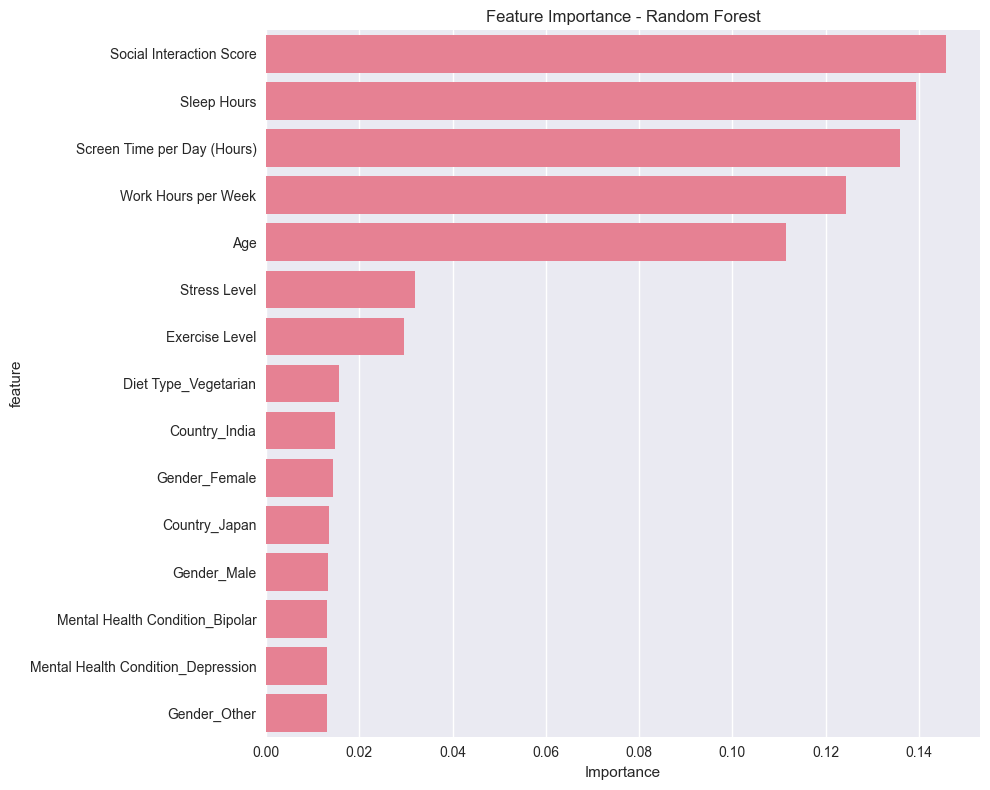

                        feature  importance
6      Social Interaction Score    0.145820
2                   Sleep Hours    0.139311
5   Screen Time per Day (Hours)    0.136057
4           Work Hours per Week    0.124326
0                           Age    0.111502
3                  Stress Level    0.031980
1                Exercise Level    0.029530
21         Diet Type_Vegetarian    0.015707
11                Country_India    0.014893
14                Gender_Female    0.014369

XGBoost Feature Importance:


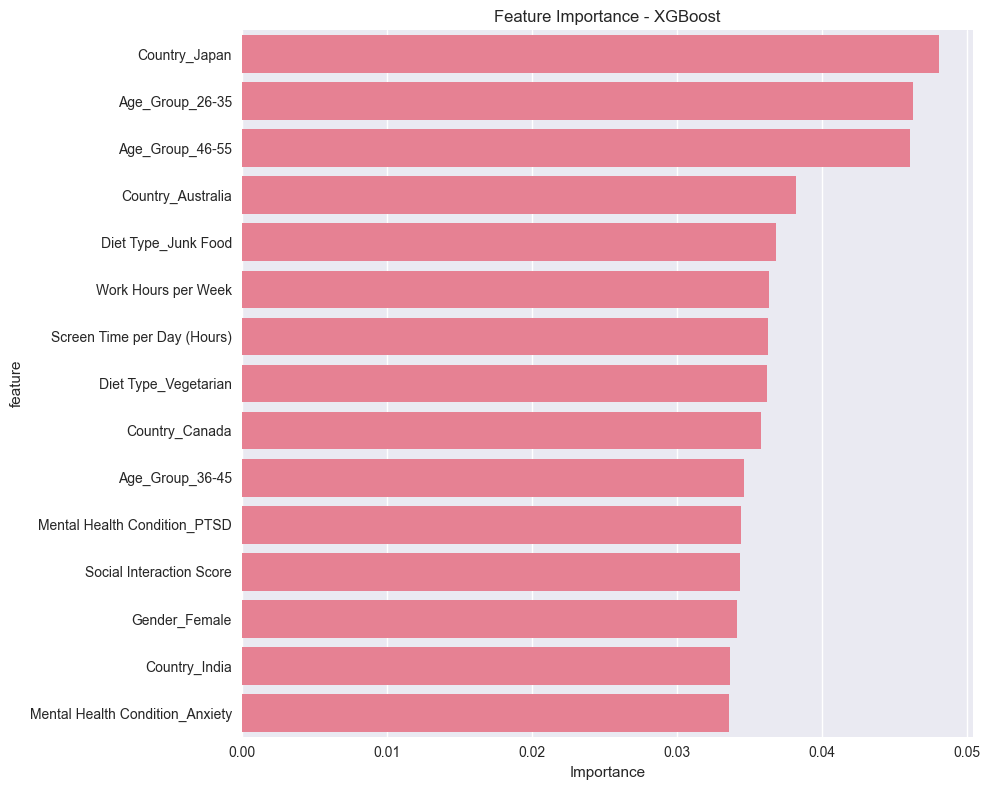

                        feature  importance
12                Country_Japan    0.048044
30              Age_Group_26-35    0.046282
32              Age_Group_46-55    0.046082
7             Country_Australia    0.038222
18          Diet Type_Junk Food    0.036871
4           Work Hours per Week    0.036354
5   Screen Time per Day (Hours)    0.036276
21         Diet Type_Vegetarian    0.036251
9                Country_Canada    0.035798
31              Age_Group_36-45    0.034622

LightGBM Feature Importance:


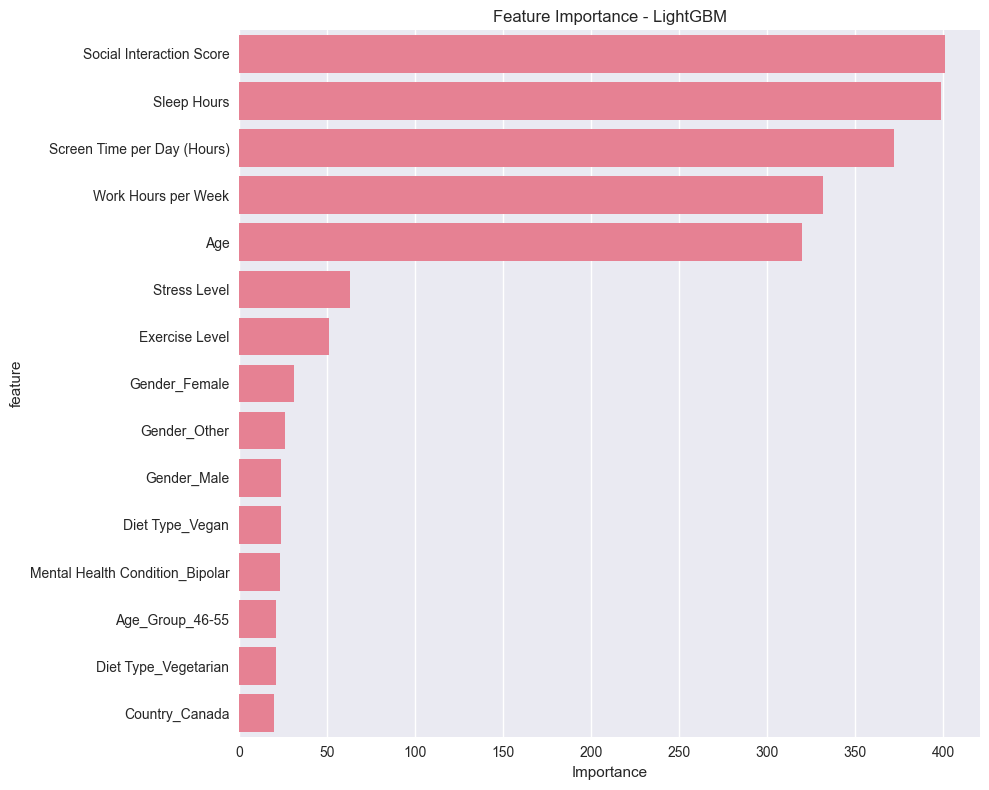

                        feature  importance
6      Social Interaction Score         401
2                   Sleep Hours         399
5   Screen Time per Day (Hours)         372
4           Work Hours per Week         332
0                           Age         320
3                  Stress Level          63
1                Exercise Level          51
14                Gender_Female          31
16                 Gender_Other          26
15                  Gender_Male          24


In [31]:
# Feature importance from tree-based models
def plot_feature_importance(model, feature_names, model_name, top_n=15):
    """Plot feature importance for tree-based models"""
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False).head(top_n)
        
        plt.figure(figsize=(10, 8))
        sns.barplot(data=feature_importance_df, x='importance', y='feature')
        plt.title(f'Feature Importance - {model_name}')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
        
        return feature_importance_df
    else:
        print(f"Model {model_name} does not have feature_importances_ attribute")
        return None

# Plot feature importance for tree-based models
feature_names = X_train_scaled.columns.tolist()

print("Feature Importance Analysis")
print("="*50)

# Random Forest
if 'Random Forest' in models_results:
    print("\nRandom Forest Feature Importance:")
    rf_importance = plot_feature_importance(
        models_results['Random Forest']['model'], 
        feature_names, 
        'Random Forest'
    )
    if rf_importance is not None:
        print(rf_importance.head(10))

# XGBoost
if 'XGBoost' in models_results:
    print("\nXGBoost Feature Importance:")
    xgb_importance = plot_feature_importance(
        models_results['XGBoost']['model'], 
        feature_names, 
        'XGBoost'
    )
    if xgb_importance is not None:
        print(xgb_importance.head(10))

# LightGBM
if 'LightGBM' in models_results:
    print("\nLightGBM Feature Importance:")
    lgb_importance = plot_feature_importance(
        models_results['LightGBM']['model'], 
        feature_names, 
        'LightGBM'
    )
    if lgb_importance is not None:
        print(lgb_importance.head(10))

## 13. Model Saving and Conclusions

In [34]:
# Save the best model and scaler
best_model_name = results_df.iloc[0]['Model']
best_model = models_results[best_model_name]['model']

print(f"Best model: {best_model_name}")
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"Dataset: {df.shape[0]} samples, {df.shape[1]} original features")
print(f"Final features after preprocessing: {X.shape[1]}")
print(f"Best model: {best_model_name}")
print(f"Best RMSE: {results_df.iloc[0]['RMSE']:.4f}")
print(f"Best R² Score: {results_df.iloc[0]['R²']:.4f}")
print("\nKey Insights:")
print("- Multiple ML algorithms were tested with hyperparameter tuning")
print("- Regularization techniques were applied to prevent overfitting")
print("- Feature engineering improved model performance")
print("- Neural networks with dropout regularization were implemented")
print("- Cross-validation was used for robust model evaluation")
print("="*60)

Best model: Ridge Regression

PROJECT SUMMARY
Dataset: 3000 samples, 12 original features
Final features after preprocessing: 34
Best model: Ridge Regression
Best RMSE: 2.5691
Best R² Score: 0.0040

Key Insights:
- Multiple ML algorithms were tested with hyperparameter tuning
- Regularization techniques were applied to prevent overfitting
- Feature engineering improved model performance
- Neural networks with dropout regularization were implemented
- Cross-validation was used for robust model evaluation
